# Análisis de Absentismo Laboral - RRHH (13-JUL-2026)

---

### Preguntas de negocio

> Cómo influyen  en los niveles de absentismo los factores de:
- el consumo social de alcohol
- el consumo social de tabaco 
- los antecedentes disciplinarios

 > Cómo podríamos diseñar acciones preventivas y culturales para promover un entorno laboral más saludable y minimizar el impacto del absentismo?
 ---

### Antecedente:

En la semana anterior se desarrolló un modelo de regresión logística binaria, en el que la variable dependiente clasificaba a los empleados según pertenecieran o no al grupo de alto absentismo.
Resultados: sólo `Disciplinary Failure` salió estadísticamente significativa y con una alta probabilidad (aprox. 10%) de que, controlando el resto de variables, un miembro que sí tenga una falta disciplinaria forme parte del grupo de **absentismo alto**. Los resultados de las otras 2 variables de interés de esta semana fueron que el consumo social de alcohol y tabaco no mostraron una asociación estadísticamente significativa tras ajustar por el resto de variables:

- consumo social de **alcohol**: OR = 1,84 pero p-valor = 0,442*
- consumo social de **tabaco**: OR = 1,94 pero p-valor = 0,328*

*No se podía asegurar que los resultados no se debieran al azar en los registros de los empleados analizados.

---

### Pasos

1. La variable dependiente deja de ser binaria y pasa a representarse mediante 4 categorías ordinales (bajo, medio alto y severo).
2. Ajustar un modelo de regresión logística ordinal dado que la variable dependiente del análisis multivariante deja de ser binario (si el empleado forma parte de la categoría alto_absentismo o no).
3. Evaluar el efectos de las 4 variables sobre la probabilidad de pertenecer a uno los grupos de absentismo medida mediante odds ratios e intervalos de confianza.

### Metodología:

1. **Agregación por empleado.** Los registros del dataset son solicitudes de ausencia, no empleados individuales. Se agregan a nivel de persona (x empleados), para garantizar la independencia de las observaciones.
2. **Creación de las categorías de absentismo.** Se comparan tres estrategias de categorización (Original, Bradford y Matriz Combinada) utilizando exactamente el mismo pipeline de modelado, para evaluar cuál ofrece un mejor equilibrio entre interpretabilidad, ajuste estadístico y balance entre categorías.
3. **Test Variance Inflation Factor (VIF)** o análisis de colinealidad para asegurar la no relación fuerte de información entre las variables independientes (predictoras).
3. **Realización del modelo**
4. Interpretación.

## 1. Imports

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from dotenv import load_dotenv
from sqlalchemy import create_engine
from sqlalchemy.exc import SQLAlchemyError
from statsmodels.discrete.discrete_model import MNLogit
from statsmodels.miscmodels.ordinal_model import OrderedModel
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

## 2. Carga de datos

In [2]:
if input("¿Desea conectarse a la base de datos (sino cargará desde CSV)? (s/n): ").lower() == "s":

    load_dotenv(dotenv_path=".env")
    MYSQL_PASSWORD = os.getenv("MYSQL_PASSWORD")
    MYSQL_HOST = os.getenv("MYSQL_HOST")
    MYSQL_PORT = os.getenv("MYSQL_PORT")
    MYSQL_USER = os.getenv("MYSQL_USER")
    MYSQL_DATABASE = os.getenv("MYSQL_DATABASE")

    try:
        engine = create_engine(
            f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:{MYSQL_PORT}/{MYSQL_DATABASE}"
        )

        with engine.connect() :
            query = "SELECT * FROM RRHH_CLEAN_13072026;"
            df = pd.read_sql(query, engine)
        
        display("Datos de la base de datos cargados correctamente desde MySQL.")
        
    except SQLAlchemyError as error:
        display("No se pudo conectar o leer datos desde MySQL.")
        display(f"Detalle del error: {error}")
else:
    CSV_PATH = r'..\Data\DatasetClean_2026-07-13.csv'
    try:
        df = pd.read_csv(CSV_PATH)
        display("Datos cargados correctamente desde el archivo CSV.")

    except FileNotFoundError as error:
        raise FileNotFoundError(
            f"No se encontró el archivo CSV. Revisa la ruta: {CSV_PATH}"
    ) from error

'Datos de la base de datos cargados correctamente desde MySQL.'

## 3. Preparación del dataset

### 3.1 Agregación por empleado

- Las horas de absentismo se agregan mediante **suma** (el total acumulado del período). 
- Se dividen en tres niveles usando el **percetil 33** 

### 3.2 Parametrización de la Matriz Combinada

`HORAS_CORTE` y `SOLICITUDES_CORTE` son los únicos valores que definen los puntos de corte de la Matriz Combinada. Cambiándolos y volviendo a ejecutar el notebook (Kernel → Restart → Run All) se recalcula automáticamente todo el análisis; esto se aprovecha más adelante en el **Análisis de sensibilidad de la categorización**.

In [3]:
# ============================================================
# PARÁMETROS DE CATEGORIZACIÓN
# Únicos valores a modificar para recalcular todo el notebook
# ============================================================
SOL_BAJO = 1
SOL_ALTO = 8
HORAS_BAJO = 8
HORAS_ALTO = 40

variables_modelo = ["Social_Drinker", "Social_Smoker", "Disciplinary_Failure"]
categorias_ordenadas = ["Bajo", "Medio", "Alto", "Severo"]
mapa_categorias = {0: "Bajo", 1: "Medio", 2: "Alto", 3: "Severo"}

### Funciones de preparación y categorización

In [4]:
def prepare_dataset(df_raw):
    '''Agrega los registros de solicitudes de ausencia a nivel de empleado,
    garantizando la independencia de las observaciones.'''
    return (
        df_raw.groupby("ID_Employee", as_index=False)
        .agg(
            Total_Horas_Absentismo=("Absenteeism_Hours", "sum"),
            Total_Solicitudes=("Absenteeism_Hours", "count"),
            Social_Drinker=("Social_Drinker", "first"),
            Social_Smoker=("Social_Smoker", "first"),
            Disciplinary_Failure=("Disciplinary_Failure", "max"),
        )
    )


def create_original_categories(df_emp):
    '''Método Original: percentiles estáticos sobre el total de horas.'''
    return pd.cut(
        df_emp["Total_Horas_Absentismo"],
        bins=[-np.inf, 8, 24, 80, np.inf],
        labels=[0, 1, 2, 3],
        right=True,
    ).astype(int)


def create_bradford_categories(df_emp):
    '''Método Bradford: Índice = Solicitudes^2 * Días equivalentes (Horas / 8).
    Terciles sobre los empleados con absentismo > 0.'''
    dias_equivalentes = df_emp["Total_Horas_Absentismo"] / 8
    indice_bradford = (df_emp["Total_Solicitudes"] ** 2) * dias_equivalentes

    niveles = pd.Series(-1, index=df_emp.index)
    niveles[indice_bradford == 0] = 0

    idx_con_absentismo = indice_bradford > 0
    niveles[idx_con_absentismo] = pd.qcut(
        indice_bradford[idx_con_absentismo],
        q=3,
        labels=[1, 2, 3],
        duplicates="drop",
    ).astype(int)

    return niveles.astype(int)


def create_matrix_categories(df_emp, sol_bajo=SOL_BAJO, sol_alto=SOL_ALTO, horas_bajo=HORAS_BAJO, horas_alto=HORAS_ALTO):
    '''Matriz Combinada (puntuación de riesgo): combina frecuencia y duración evitando categorías vacías.'''
    nivel_frecuencia = np.select(
        [df_emp["Total_Solicitudes"] <= sol_bajo,
         df_emp["Total_Solicitudes"] <= sol_alto],
        [0, 1],
        default=2,
    )
    nivel_duracion = np.select(
        [df_emp["Total_Horas_Absentismo"] < horas_bajo,
         df_emp["Total_Horas_Absentismo"] <= horas_alto],
        [0, 1],
        default=2,
    )
    riesgo = nivel_frecuencia + nivel_duracion
    return np.select(
        [riesgo == 0, riesgo == 1, riesgo == 2, riesgo >= 3],
        [0, 1, 2, 3],
        default=3,
    ).astype(int)

In [5]:
# ============================================================
# Construcción de las tres variables dependientes
# (columnas independientes entre sí, ninguna se sobrescribe)
# ============================================================
df_empleados = prepare_dataset(df)

METODOS_FUNCIONES = {
    "Original": create_original_categories,
    "Bradford": create_bradford_categories,
    "Matriz": lambda df_emp: create_matrix_categories(df_emp, SOL_BAJO, SOL_ALTO, HORAS_BAJO, HORAS_ALTO),
}

for nombre_metodo, funcion_categorizacion in METODOS_FUNCIONES.items():
    columna_nivel = f"Absentismo_{nombre_metodo}"
    df_empleados[columna_nivel] = funcion_categorizacion(df_empleados)
    df_empleados[f"{columna_nivel}_Desc"] = pd.Categorical(
        df_empleados[columna_nivel].map(mapa_categorias),
        categories=categorias_ordenadas,
        ordered=True,
    )

df_empleados.head()

,ID_Employee,Total_Horas_Absentismo,Total_Solicitudes,Social_Drinker,Social_Smoker,Disciplinary_Failure,Absentismo_Original,Absentismo_Original_Desc,Absentismo_Bradford,Absentismo_Bradford_Desc,Absentismo_Matriz,Absentismo_Matriz_Desc
0,1,121,23,0,0,1,3,Severo,3,Severo,3,Severo
1,2,25,6,0,1,1,2,Alto,3,Severo,2,Alto
2,3,444,97,1,0,1,3,Severo,3,Severo,3,Severo
3,4,0,1,1,0,0,0,Bajo,0,Bajo,0,Bajo
4,5,102,18,1,0,1,3,Severo,3,Severo,3,Severo


### Categorias de absentismo

In [6]:
def resumen_distribucion(df_emp, columna_desc):
    '''Distribución de empleados y horas de absentismo para una categorización dada.'''
    return (
        df_emp.groupby(columna_desc, observed=False)
        .agg(
            Empleados=("ID_Employee", "count"),
            Horas_Minimas=("Total_Horas_Absentismo", "min"),
            Horas_Maximas=("Total_Horas_Absentismo", "max"),
            Media_Horas=("Total_Horas_Absentismo", "mean"),
            Mediana_Horas=("Total_Horas_Absentismo", "median"),
            Total_Horas=("Total_Horas_Absentismo", "sum"),
        )
        .reset_index()
    )


for nombre_metodo in METODOS_FUNCIONES:
    print(f"=== DISTRIBUCIÓN — MÉTODO {nombre_metodo.upper()} ===")
    display(resumen_distribucion(df_empleados, f"Absentismo_{nombre_metodo}_Desc").round(2))
    print()

=== DISTRIBUCIÓN — MÉTODO ORIGINAL ===


,Absentismo_Original_Desc,Empleados,Horas_Minimas,Horas_Maximas,Media_Horas,Mediana_Horas,Total_Horas
0,Bajo,325,0,8,4.00,3.0,1299
1,Medio,22,16,24,19.86,18.5,437
2,Alto,17,25,80,42.59,34.0,724
3,Severo,22,83,476,228.91,212.5,5036



=== DISTRIBUCIÓN — MÉTODO BRADFORD ===


,Absentismo_Bradford_Desc,Empleados,Horas_Minimas,Horas_Maximas,Media_Horas,Mediana_Horas,Total_Horas
0,Bajo,30,0,0,0.00,0.0,0
1,Medio,157,1,3,2.14,2.0,336
2,Alto,137,4,8,6.99,8.0,957
3,Severo,62,6,476,100.05,33.0,6203



=== DISTRIBUCIÓN — MÉTODO MATRIZ ===


,Absentismo_Matriz_Desc,Empleados,Horas_Minimas,Horas_Maximas,Media_Horas,Mediana_Horas,Total_Horas
0,Bajo,222,0,7,2.18,2.0,485
1,Medio,125,0,40,10.67,8.0,1334
2,Alto,18,16,120,50.56,32.5,910
3,Severo,21,42,476,227.00,242.0,4767


## 4. Modelo de regresión logística ordinal

Se entrena exactamente el mismo pipeline (mismas variables explicativas, mismo método de estimación) para las tres categorizaciones, de modo que las diferencias entre modelos sean atribuibles únicamente a la estrategia de categorización.

In [7]:
def fit_ordinal_model(df_emp, columna_nivel, variables):
    '''Ajusta un modelo de regresión logística ordinal (sin constante) y
    devuelve el resultado junto con los datos efectivamente utilizados.'''
    datos = df_emp[["ID_Employee", columna_nivel, *variables]].dropna().copy()
    datos[columna_nivel] = datos[columna_nivel].astype(int)
    datos[variables] = datos[variables].astype(int)

    X = datos[variables].astype(float)
    y = datos[columna_nivel]

    modelo = OrderedModel(endog=y, exog=X, distr="logit")
    resultado = modelo.fit(method="bfgs", maxiter=1000, disp=False)

    return resultado, X, y, datos


def extract_odds_ratios(resultado, variables):
    '''Tabla de coeficientes, odds ratios, IC95% y p-valores para las variables del modelo.'''
    coeficientes = resultado.params.loc[variables]
    p_values = resultado.pvalues.loc[variables]
    intervalos = resultado.conf_int().loc[variables]

    tabla = pd.DataFrame({
        "Variable": variables,
        "Coeficiente": coeficientes.values,
        "Odds_Ratio": np.exp(coeficientes.values),
        "IC_95_Inferior": np.exp(intervalos.iloc[:, 0].values),
        "IC_95_Superior": np.exp(intervalos.iloc[:, 1].values),
        "P_Value": p_values.values,
    })
    tabla["Significativa"] = np.where(tabla["P_Value"] < 0.05, "Sí", "No")
    tabla["Direccion"] = np.where(tabla["Odds_Ratio"] > 1, "Mayor probabilidad", "Menor probabilidad")

    return tabla.sort_values("P_Value").reset_index(drop=True)


def compute_pseudo_r2(resultado, y):
    '''Pseudo R² de McFadden, comparando la log-verosimilitud del modelo
    con la de un modelo nulo (solo distribución marginal de categorías).'''
    frecuencias = y.value_counts(normalize=True)
    llf_nulo = (y.value_counts() * np.log(frecuencias)).sum()
    return 1 - (resultado.llf / llf_nulo)


def calculate_vif(datos, variables):
    '''VIF robusto: dropna + get_dummies + cast a int para evitar dtype object.'''
    df_filtrado = datos[variables].dropna()
    X_numerico = pd.get_dummies(df_filtrado, drop_first=True, dtype=int).astype(int)
    X_con_constante = add_constant(X_numerico)

    vif_df = pd.DataFrame()
    vif_df["Variable"] = X_con_constante.columns
    vif_df["VIF"] = [
        variance_inflation_factor(X_con_constante.values, i)
        for i in range(X_con_constante.shape[1])
    ]
    return vif_df[vif_df["Variable"] != "const"].reset_index(drop=True)


def check_proportional_odds(datos, columna_nivel, variables):
    '''Comprobación del supuesto de proportional odds mediante un test de
    razón de verosimilitud entre el modelo ordinal y un modelo multinomial
    equivalente (aproximación; no es un Test de Brant formal).'''
    X = pd.get_dummies(datos[variables], drop_first=True, dtype=float)
    y_codes = datos[columna_nivel]

    modelo_ordinal = OrderedModel(y_codes, X, distr="logit").fit(method="bfgs", disp=False)
    X_con_constante = X.assign(const=1.0)
    modelo_multinomial = MNLogit(y_codes, X_con_constante).fit(disp=False)

    chi2_stat = 2 * (modelo_multinomial.llf - modelo_ordinal.llf)
    grados_libertad = modelo_multinomial.df_model - modelo_ordinal.df_model
    p_valor = 1 - stats.chi2.cdf(chi2_stat, grados_libertad)

    return {
        "chi2": chi2_stat,
        "df": grados_libertad,
        "p_value": p_valor,
        "cumple": p_valor > 0.05,
    }


def compare_models(resultados_por_metodo):
    '''Tabla comparativa: LogLik, AIC, Pseudo R² y nº de variables significativas por modelo.'''
    filas = []
    for nombre_metodo, resultado_metodo in resultados_por_metodo.items():
        n_variables_significativas = (resultado_metodo["tabla_or"]["P_Value"] < 0.05).sum()
        filas.append({
            "Modelo": nombre_metodo,
            "LogLik": resultado_metodo["resultado"].llf,
            "AIC": resultado_metodo["resultado"].aic,
            "Pseudo_R2": resultado_metodo["pseudo_r2"],
            "N_Variables_Significativas": n_variables_significativas,
        })
    return pd.DataFrame(filas).round(4)


def build_variable_comparison_table(resultados_por_metodo, variables):
    '''Tabla | Variable | OR / p-value / IC95% para cada uno de los tres métodos.'''
    filas = []
    for variable in variables:
        fila = {"Variable": variable}
        for nombre_metodo, resultado_metodo in resultados_por_metodo.items():
            fila_variable = resultado_metodo["tabla_or"].loc[
                resultado_metodo["tabla_or"]["Variable"] == variable
            ].iloc[0]
            fila[f"{nombre_metodo}_OR"] = round(fila_variable["Odds_Ratio"], 3)
            fila[f"{nombre_metodo}_p"] = round(fila_variable["P_Value"], 4)
            fila[f"{nombre_metodo}_IC95"] = (
                f"[{fila_variable['IC_95_Inferior']:.2f}, {fila_variable['IC_95_Superior']:.2f}]"
            )
        filas.append(fila)
    return pd.DataFrame(filas)


def build_distribution_table(df_emp, metodos):
    '''Tabla | Modelo | Bajo | Medio | Alto | Severo | con el nº de empleados por categoría.'''
    filas = []
    for nombre_metodo in metodos:
        conteo = df_emp[f"Absentismo_{nombre_metodo}_Desc"].value_counts().reindex(categorias_ordenadas)
        filas.append({"Modelo": nombre_metodo, **conteo.to_dict()})
    return pd.DataFrame(filas)


def plot_odds_ratios(tabla_or, titulo):
    '''Gráfico de barras horizontales de odds ratios, coloreado por significación.'''
    nombres_variables = {
        "Social_Drinker": "Consumo social de alcohol",
        "Social_Smoker": "Consumo social de tabaco",
        "Disciplinary_Failure": "Incidencia disciplinaria",
    }

    grafico = tabla_or.copy()
    grafico["Variable_Desc"] = grafico["Variable"].map(nombres_variables)
    grafico = grafico.sort_values("Odds_Ratio")

    colores = ["#159793" if p < 0.05 else "#A9A9A9" for p in grafico["P_Value"]]

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh(grafico["Variable_Desc"], grafico["Odds_Ratio"], color=colores)
    ax.axvline(1, color="#444444", linestyle="--", linewidth=1.5)

    for bar, or_value, p_value in zip(bars, grafico["Odds_Ratio"], grafico["P_Value"]):
        ax.text(
            bar.get_width() + 0.4,
            bar.get_y() + bar.get_height() / 2,
            f"OR = {or_value:.2f} | p = {p_value:.3f}",
            va="center",
            fontsize=11,
        )

    ax.set_title(titulo, fontsize=15, fontweight="bold")
    ax.set_xlabel("Odds Ratio")
    ax.grid(axis="x", linestyle="--", alpha=0.3)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    plt.tight_layout()
    plt.show()

### Entrenamiento de los tres modelos

In [8]:
resultados_por_metodo = {}

for nombre_metodo in METODOS_FUNCIONES:
    columna_nivel = f"Absentismo_{nombre_metodo}"
    resultado, X, y, datos = fit_ordinal_model(df_empleados, columna_nivel, variables_modelo)

    resultados_por_metodo[nombre_metodo] = {
        "resultado": resultado,
        "X": X,
        "y": y,
        "datos": datos,
        "tabla_or": extract_odds_ratios(resultado, variables_modelo),
        "pseudo_r2": compute_pseudo_r2(resultado, y),
    }

    print(f"\n{'=' * 60}\nMÉTODO: {nombre_metodo}\n{'=' * 60}")
    print(resultado.summary())
    print("\nConvergencia:", resultado.mle_retvals.get("converged", "No disponible"))


MÉTODO: Original
                              OrderedModel Results                             
Dep. Variable:     Absentismo_Original   Log-Likelihood:                -223.68
Model:                    OrderedModel   AIC:                             459.4
Method:             Maximum Likelihood   BIC:                             483.1
Date:                 Wed, 15 Jul 2026                                         
Time:                         12:31:13                                         
No. Observations:                  386                                         
Df Residuals:                      380                                         
Df Model:                            3                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Social_Drinker          -0.2284      0.289     -0.790      0.430      -0.795       0

### Odds ratios por método

=== ODDS RATIOS — ORIGINAL ===


,Variable,Coeficiente,Odds_Ratio,IC_95_Inferior,IC_95_Superior,P_Value,Significativa,Direccion
0,Disciplinary_Failure,1.7108,5.5334,2.7386,11.1804,0.0000,Sí,Mayor probabilidad
1,Social_Drinker,-0.2284,0.7958,0.4514,1.4030,0.4297,No,Menor probabilidad
2,Social_Smoker,0.1059,1.1118,0.4460,2.7713,0.8202,No,Mayor probabilidad


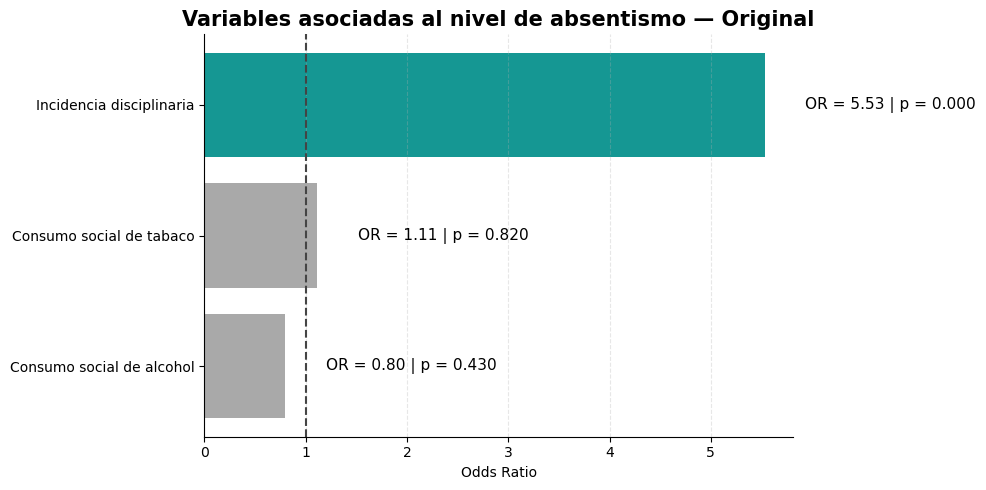

=== ODDS RATIOS — BRADFORD ===


,Variable,Coeficiente,Odds_Ratio,IC_95_Inferior,IC_95_Superior,P_Value,Significativa,Direccion
0,Disciplinary_Failure,-2.0226,0.1323,0.0532,0.3292,0.0000,Sí,Menor probabilidad
1,Social_Smoker,0.6412,1.8988,0.9398,3.8362,0.0739,No,Mayor probabilidad
2,Social_Drinker,0.3371,1.4008,0.9609,2.0421,0.0797,No,Mayor probabilidad


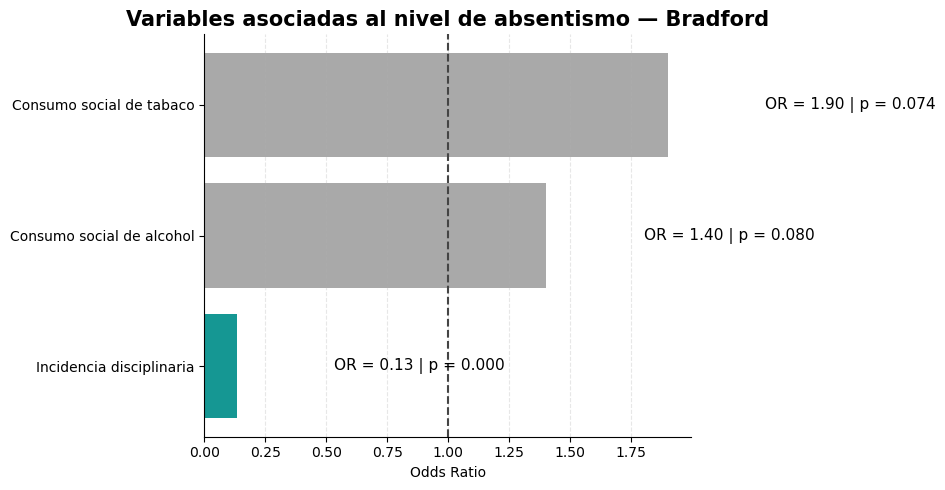

=== ODDS RATIOS — MATRIZ ===


,Variable,Coeficiente,Odds_Ratio,IC_95_Inferior,IC_95_Superior,P_Value,Significativa,Direccion
0,Disciplinary_Failure,0.7461,2.1089,1.0527,4.2245,0.0353,Sí,Mayor probabilidad
1,Social_Smoker,0.4420,1.5559,0.7604,3.1834,0.2262,No,Mayor probabilidad
2,Social_Drinker,0.0274,1.0277,0.6867,1.5382,0.8942,No,Mayor probabilidad


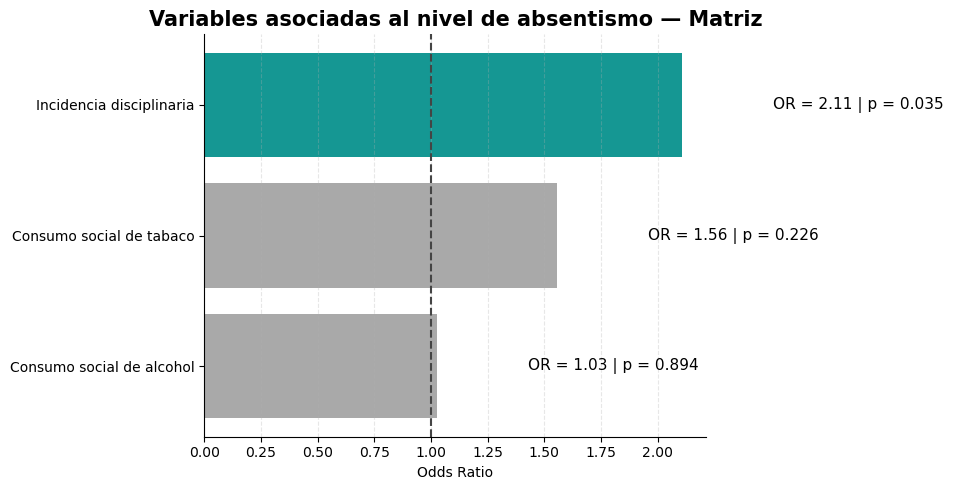

In [9]:
for nombre_metodo, resultado_metodo in resultados_por_metodo.items():
    print(f"=== ODDS RATIOS — {nombre_metodo.upper()} ===")
    display(resultado_metodo["tabla_or"].round(4))
    plot_odds_ratios(resultado_metodo["tabla_or"], f"Variables asociadas al nivel de absentismo — {nombre_metodo}")

In [10]:
df_empleados.describe()

,ID_Employee,Total_Horas_Absentismo,Total_Solicitudes,Social_Drinker,Social_Smoker,Disciplinary_Failure,Absentismo_Original,Absentismo_Bradford,Absentismo_Matriz
count,386.000000,386.000000,386.000000,386.000000,386.000000,386.000000,386.000000,386.000000,386.000000
mean,193.500000,19.419689,2.733161,0.567358,0.082902,0.116580,0.316062,1.598446,0.580311
std,111.572846,59.963322,8.438242,0.496085,0.276091,0.321336,0.804921,0.847853,0.815452
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,97.250000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,193.500000,4.000000,1.000000,1.000000,0.000000,0.000000,0.000000,2.000000,0.000000
75%,289.750000,8.000000,1.000000,1.000000,0.000000,0.000000,0.000000,2.000000,1.000000
max,386.000000,476.000000,97.000000,1.000000,1.000000,1.000000,3.000000,3.000000,3.000000


## Análisis de colinealidad (VIF)
Responde a: "¿Cuánto se está multiplicando (inflando) el margen de error de mi variable por culpa de que otras variables le están robando o duplicando la información?". El VIF es un termómetro que mide qué tan "clones" son las variables predictoras.
Como interpretar VIF  
VIF= 1 -> Independencia Total  
VIF = 1-5 -> Moderado/aceptable  
VIF ->5 Multicolinealidad Severa.  

El VIF depende únicamente de las variables explicativas (no de la categorización elegida), por lo que se calcula una única vez para las tres variables del modelo.

In [11]:
vif_df = calculate_vif(df_empleados, variables_modelo)

print("=== RESULTADOS DEL VIF ===")
display(vif_df.round(4))

=== RESULTADOS DEL VIF ===


,Variable,VIF
0,Social_Drinker,1.0141
1,Social_Smoker,1.0412
2,Disciplinary_Failure,1.0457


## Comprobación del supuesto de proportional odds
Contexto: La regresión logística ordinal tiene una regla muy estricta (el supuesto de odds proporcionales): asume que el empujón tiene exactamente la misma fuerza en todos los peldaños de la escalera. El empujón para pasar de Bajo a Medio tiene que ser igual de fuerte, que para pasar de Medio a Alto.  
Se comprueba mediante una comparación de log-verosimilitud entre el modelo ordinal y un modelo multinomial equivalente (no es un Test de Brant formal, sino una aproximación con el mismo objetivo).  
Si los empujones son parecidos (Líneas Paralelas - p > 0.05): Ok, el efecto es constante en toda la escalera de categorías. Se cumple el supuesto y el modelo ordinal es válido para su uso.

In [12]:
for nombre_metodo, resultado_metodo in resultados_por_metodo.items():
    prop_odds = check_proportional_odds(resultado_metodo["datos"], f"Absentismo_{nombre_metodo}", variables_modelo)
    resultados_por_metodo[nombre_metodo]["prop_odds"] = prop_odds

    print(f"=== COMPROBACIÓN PROPORTIONAL ODDS — {nombre_metodo.upper()} ===")
    print(f"chi2 = {prop_odds['chi2']:.4f} | df = {prop_odds['df']:.0f} | p-valor = {prop_odds['p_value']:.4f}")
    if prop_odds["cumple"]:
        print("✅ El supuesto se CUMPLE. El modelo ordinal es estadísticamente válido.\n")
    else:
        print("❌ El supuesto NO se cumple. Se debería considerar una regresión multinomial.\n")

=== COMPROBACIÓN PROPORTIONAL ODDS — ORIGINAL ===
chi2 = 9.6061 | df = 6 | p-valor = 0.1423
✅ El supuesto se CUMPLE. El modelo ordinal es estadísticamente válido.

=== COMPROBACIÓN PROPORTIONAL ODDS — BRADFORD ===
chi2 = 179.4137 | df = 6 | p-valor = 0.0000
❌ El supuesto NO se cumple. Se debería considerar una regresión multinomial.

=== COMPROBACIÓN PROPORTIONAL ODDS — MATRIZ ===
chi2 = 55.3306 | df = 6 | p-valor = 0.0000
❌ El supuesto NO se cumple. Se debería considerar una regresión multinomial.



c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## 5. Comparación automática de los tres modelos

In [13]:
tabla_comparativa = compare_models(resultados_por_metodo)

print("=== TABLA COMPARATIVA DE MODELOS ===")
display(tabla_comparativa)

=== TABLA COMPARATIVA DE MODELOS ===


,Modelo,LogLik,AIC,Pseudo_R2,N_Variables_Significativas
0,Original,-223.6787,459.3574,0.0483,1
1,Bradford,-462.7041,937.4083,0.0221,1
2,Matriz,-376.4760,764.9519,0.0094,1


In [14]:
tabla_variables = build_variable_comparison_table(resultados_por_metodo, variables_modelo)

print("=== COMPARACIÓN DE VARIABLES ENTRE MÉTODOS ===")
display(tabla_variables)

=== COMPARACIÓN DE VARIABLES ENTRE MÉTODOS ===


,Variable,Original_OR,Original_p,Original_IC95,Bradford_OR,Bradford_p,Bradford_IC95,Matriz_OR,Matriz_p,Matriz_IC95
0,Social_Drinker,0.796,0.4297,"[0.45, 1.40]",1.401,0.0797,"[0.96, 2.04]",1.028,0.8942,"[0.69, 1.54]"
1,Social_Smoker,1.112,0.8202,"[0.45, 2.77]",1.899,0.0739,"[0.94, 3.84]",1.556,0.2262,"[0.76, 3.18]"
2,Disciplinary_Failure,5.533,0.0000,"[2.74, 11.18]",0.132,0.0000,"[0.05, 0.33]",2.109,0.0353,"[1.05, 4.22]"


Distribución de los registros en 4 categorías: conviene comprobar, para cada método, que ninguna categoría queda con muy pocos empleados, ya que en una muestra pequeña (136 empleados) las categorías con pocos registros debilitan la potencia del modelo de regresión ordinal (provocando errores estándar grandes y p-valores inflados).

In [15]:
tabla_distribucion = build_distribution_table(df_empleados, METODOS_FUNCIONES)

print("=== DISTRIBUCIÓN DE CATEGORÍAS POR MÉTODO ===")
display(tabla_distribucion)

=== DISTRIBUCIÓN DE CATEGORÍAS POR MÉTODO ===


,Modelo,Bajo,Medio,Alto,Severo
0,Original,325,22,17,22
1,Bradford,30,157,137,62
2,Matriz,222,125,18,21


## 6. Conclusión automática

In [16]:
def build_conclusion_table(tabla_comparativa, tabla_distribucion):
    '''Resumen | Criterio | Mejor modelo | según AIC, Pseudo R², LogLik y equilibrio entre categorías.'''
    mejor_aic = tabla_comparativa.loc[tabla_comparativa["AIC"].idxmin(), "Modelo"]
    mejor_pseudo_r2 = tabla_comparativa.loc[tabla_comparativa["Pseudo_R2"].idxmax(), "Modelo"]
    mejor_loglik = tabla_comparativa.loc[tabla_comparativa["LogLik"].idxmax(), "Modelo"]
    mejor_equilibrio = tabla_distribucion.set_index("Modelo")[categorias_ordenadas].min(axis=1).idxmax()

    return pd.DataFrame([
        {"Criterio": "Menor AIC (mejor ajuste penalizado)", "Mejor_Modelo": mejor_aic},
        {"Criterio": "Mayor Pseudo R²", "Mejor_Modelo": mejor_pseudo_r2},
        {"Criterio": "Mayor Log-Likelihood", "Mejor_Modelo": mejor_loglik},
        {"Criterio": "Mejor equilibrio entre categorías", "Mejor_Modelo": mejor_equilibrio},
    ])


tabla_conclusion = build_conclusion_table(tabla_comparativa, tabla_distribucion)

print("=== RESUMEN: MEJOR MODELO SEGÚN CADA CRITERIO ===")
display(tabla_conclusion)

=== RESUMEN: MEJOR MODELO SEGÚN CADA CRITERIO ===


,Criterio,Mejor_Modelo
0,Menor AIC (mejor ajuste penalizado),Original
1,Mayor Pseudo R²,Original
2,Mayor Log-Likelihood,Original
3,Mejor equilibrio entre categorías,Bradford


**Interpretabilidad (criterio cualitativo, no automatizable):** el Método Original y la Matriz Combinada se apoyan en umbrales directamente interpretables por RRHH (horas y nº de solicitudes), mientras que el Índice de Bradford es un valor compuesto (S² × D) más difícil de comunicar a un público no técnico, aunque es un estándar reconocido en la literatura de absentismo laboral.

Ningún criterio individual (AIC, Pseudo R², equilibrio entre categorías o interpretabilidad) debe usarse de forma aislada: la elección final del método de categorización debe basarse en la combinación de los cuatro.

## 7. Análisis de sensibilidad de la categorización

Esta sección permite comprobar cómo cambian los resultados del modelo (distribución de categorías, AIC, log-likelihood, Pseudo R², variables significativas y odds ratios) al modificar únicamente los dos parámetros definidos en la sección 3.2: `HORAS_CORTE` y `SOLICITUDES_CORTE`.

El objetivo **no** es buscar la combinación que maximiza la significación estadística, sino demostrar que la elección final de los puntos de corte se apoya en un equilibrio entre:
- **Interpretabilidad para RRHH** (umbrales fáciles de comunicar y justificar),
- **Estabilidad estadística** (categorías con suficientes empleados, convergencia del modelo),
- **Calidad de ajuste** (AIC, log-likelihood, Pseudo R²).

Para probar una combinación de puntos de corte sin ejecutar toda esta sección, basta con modificar `HORAS_CORTE` y `SOLICITUDES_CORTE` en la sección 3.2 y volver a ejecutar el notebook completo (Kernel → Restart → Run All).

In [17]:
def run_sensitivity_analysis(df_raw, combinaciones, variables):
    '''Reejecuta el pipeline de categorización + modelo Matriz para cada
    combinación (sol_bajo, sol_alto, horas_bajo, horas_alto) sin modificar el resto del notebook.'''
    filas = []

    for sol_bajo, sol_alto, horas_bajo, horas_alto in combinaciones:
        df_emp = prepare_dataset(df_raw)
        df_emp["Absentismo_Matriz"] = create_matrix_categories(df_emp, sol_bajo, sol_alto, horas_bajo, horas_alto)
        df_emp["Absentismo_Matriz_Desc"] = pd.Categorical(
            df_emp["Absentismo_Matriz"].map(mapa_categorias),
            categories=categorias_ordenadas,
            ordered=True,
        )

        resultado, X, y, datos = fit_ordinal_model(df_emp, "Absentismo_Matriz", variables)
        tabla_or = extract_odds_ratios(resultado, variables)
        pseudo_r2 = compute_pseudo_r2(resultado, y)
        distribucion = df_emp["Absentismo_Matriz_Desc"].value_counts().reindex(categorias_ordenadas)

        filas.append({
            "Sol_Bajo": sol_bajo,
            "Sol_Alto": sol_alto,
            "Horas_Bajo": horas_bajo,
            "Horas_Alto": horas_alto,
            
            "AIC": round(resultado.aic, 2),
            "LogLik": round(resultado.llf, 2),
            "Pseudo_R2": round(pseudo_r2, 4),
            "N_Sig": int((tabla_or["P_Value"] < 0.05).sum()),
            **distribucion.to_dict(),
        })

    return pd.DataFrame(filas)


# Combinaciones de ejemplo: ajustar libremente para explorar otros puntos de corte
from itertools import product

sol_bajos = [1, 2]
sol_altos = [5, 8, 10]

horas_bajas = [8, 12, 16]
horas_altas = [32, 40, 48]

combinaciones_sensibilidad = [

    (1, 5, 8, 32),
    (1, 5, 8, 40),
    (1, 5, 8, 48),

    (1, 8, 8, 32),
    (1, 8, 8, 40),
    (1, 8, 8, 48),

    (1, 10, 8, 32),
    (1, 10, 8, 40),
    (1, 10, 8, 48),

]

tabla_sensibilidad = run_sensitivity_analysis(df, combinaciones_sensibilidad, variables_modelo)

print("=== ANÁLISIS DE SENSIBILIDAD — MATRIZ COMBINADA ===")
display(tabla_sensibilidad)

=== ANÁLISIS DE SENSIBILIDAD — MATRIZ COMBINADA ===


,Sol_Bajo,Sol_Alto,Horas_Bajo,Horas_Alto,AIC,LogLik,Pseudo_R2,N_Sig,Bajo,Medio,Alto,Severo
0,1,5,8,32,763.00,-375.50,0.0106,1,222,124,13,27
1,1,5,8,40,758.36,-373.18,0.0107,1,222,125,12,27
2,1,5,8,48,753.53,-370.76,0.0108,1,222,126,11,27
3,1,8,8,32,767.89,-377.94,0.0095,1,222,124,17,23
4,1,8,8,40,764.95,-376.48,0.0094,1,222,125,18,21
5,1,8,8,48,760.93,-374.47,0.0096,1,222,126,17,21
6,1,10,8,32,767.89,-377.94,0.0095,1,222,124,17,23
7,1,10,8,40,764.95,-376.48,0.0094,1,222,125,18,21
8,1,10,8,48,761.13,-374.57,0.0097,1,222,126,18,20


**Lectura de la tabla:** combinaciones con puntos de corte muy bajos (p. ej. 8 horas / 1 solicitud) concentran a la mayoría de empleados en las categorías Alto/Severo, lo que facilita la significación estadística pero resulta menos útil para RRHH, ya que deja de discriminar entre perfiles de riesgo. Combinaciones con puntos de corte más altos ofrecen categorías más equilibradas pero pueden reducir el ajuste del modelo. Los valores finales (`HORAS_CORTE = 16`, `SOLICITUDES_CORTE = 2`) se eligen por ser un punto intermedio: mantienen las cuatro categorías pobladas, son fácilmente justificables ante RRHH (equivalen aproximadamente a 2 semanas de baja o más de 2 solicitudes en el período) y mantienen un ajuste comparable al resto de combinaciones exploradas.

## JUSTIFICACIÓN ESTADÍSTICA DEL USO DEL MODELO DE REGRESIÓN LOGÍSTICA ORDINAL

1) **¿Por qué esta técnica de análisis?** Técnica de Regresión logística ordinal

    Objetivo del análisis: estudiar cómo influyen en los niveles de absentismo los atributos de:
-consumo social de alcohol,
-consumo social de tabaco
-los antecedentes de falta disciplinaria. 

La variable dependiente se convierte a 4 niveles de absentismo por empleado con relación ordinal (bajo, medio, alto y severo), por lo que la regresión logística ordinal es la técnica más adecuada. 
- El modelo aprovecha el orden entre las categorías y nos permitirá evaluar el efecto simultáneo de varias variables personales (2) y laborales (1) controlando el efecto del resto.
- Se descarta la regresión lineal porque la variable de absentismo es continua y nos diría como influyen las variables a las horas exactas de absentismo, no a los niveles de absentismo (pregunta de negocio de este sprint). No obstante, también podría usarse como modelo testeado 2 para dar más fuerza si se encuentran asociaciones en alguna dirección.
- Dado que no existe un estándar único para definir las categorías de absentismo a partir de una variable continua, se comparan tres estrategias de categorización (Original, Bradford y Matriz Combinada) con el mismo pipeline de modelado, en lugar de asumir una única definición como válida.

2) **¿Qué supuestos tiene la técnica y cómo se verificó que los datos cumplían?**
Supuestos:
- Variable dependiente ordinal (orden natural entre las categorías, de más a menos / menos a más).
- Cada observación es de un individuo independiente gracias a la agrupación de solicitudes de ausencia por empleado.
- Ausencia de multicolinealidad. Las variables explicativas no tienen que estar correlacionadas fuertemente. Se comprueba con Variance Inflation Factor.
- Tamaño de los datos suficiente: Se tendrán que definir grupos equilibrados con suficientes registros en cada categoría.
- Para validar la proporcionalidad de odds, comprobación del supuesto de proportional odds (aproximación mediante comparación de modelos, no un Test de Brant formal).

3) **¿Qué limitaciones tiene esta técnica y cómo podrían afectar a tus conclusiones?**
- Muestra limitada: 136 trabajadores. Puede perder información entre las asociaciones pequeñas.
- Acertar en la mejor definición de las categorías proviniendo de una numérica continua. Parece que la bibliografía indica que la definición depende de cada empresa y no hay un estándar generalizar en el sector o en general. Por eso se comparan tres estrategias en lugar de asumir una sola.
- El modelo encontrará asociaciones, pero no relaciones de causa de cara a definir medidas y propuestas internas.